Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 412ms/step - accuracy: 0.8115 - loss: 0.1056 - val_accuracy: 0.8142 - val_loss: 0.0736
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 414ms/step - accuracy: 0.8152 - loss: 0.0723 - val_accuracy: 0.8143 - val_loss: 0.0699
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - accuracy: 0.8153 - loss: 0.0697 - val_accuracy: 0.8144 - val_loss: 0.0682
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 408ms/step - accuracy: 0.8154 - loss: 0.0683 - val_accuracy: 0.8144 - val_loss: 0.0672
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 414ms/step - accuracy: 0.8154 - loss: 0.0673 - val_accuracy: 0.8144 - val_loss: 0.0664
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - accuracy: 0.8154 - loss: 0.0667 - val_accuracy: 0.8145 - val_loss: 0.0658
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 188s 402ms/step - accuracy: 0.8154 - loss: 0.0661 - val_accuracy: 0.8145 - val_loss: 0.0654
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 405ms/step - accuracy: 0.8155 -

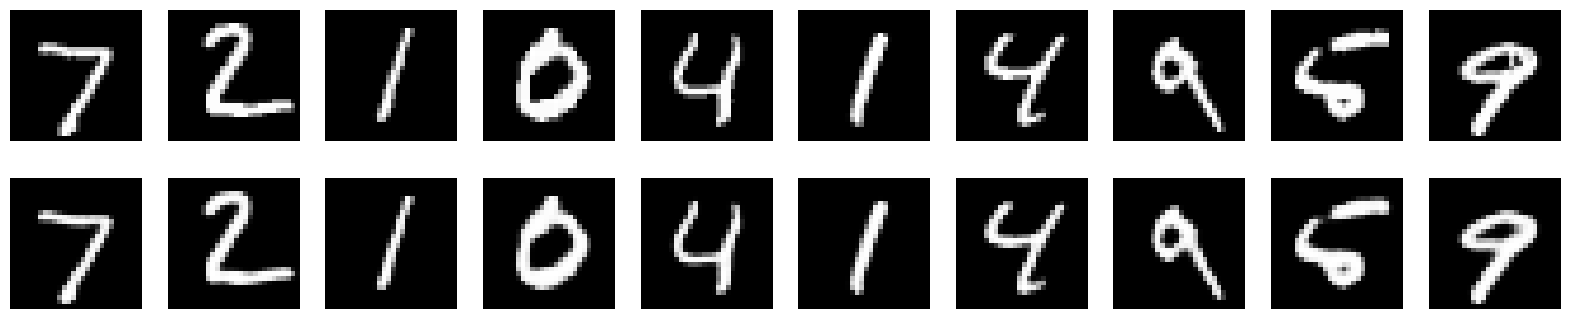

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

decoded = layers.Conv2D(
    1,
    3,
    activation='sigmoid',
    padding='same'
)(x)

# Resize output to exactly 28x28
decoded = layers.Resizing(28, 28)(decoded)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

loss, accuracy = autoencoder.evaluate(x_test, x_test)

print("Accuracy :", round(accuracy * 100, 2), "%")

decoded_imgs = autoencoder.predict(x_test[:10])

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()